In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

df = pd.read_csv('telco_churn.csv')

print(df.shape)
print(df.columns.tolist())
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

(4225, 52)
['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn', 'Churn Category', 'Churn Reason', 'Churn Score', 'City', 'CLTV', 'Contract', 'Country', 'Customer ID', 'Customer Status', 'Dependents', 'Device Protection Plan', 'Gender', 'Internet Service', 'Internet Type', 'Lat Long', 'Latitude', 'Longitude', 'Married', 'Monthly Charge', 'Multiple Lines', 'Number of Dependents', 'Number of Referrals', 'Offer', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Payment Method', 'Phone Service', 'Population', 'Premium Tech Support', 'Quarter', 'Referred a Friend', 'Satisfaction Score', 'Senior Citizen', 'State', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data', 'Zip Code']
Churn
0    3104
1    1121
Name: count, dtype: int64
Churn
0    73.467456
1    26.532544
Name: proportion, dtyp

In [2]:
df = df[['Tenure in Months', 
         'Monthly Charge',
         'Contract',
         'Satisfaction Score',
         'Number of Referrals',
         'Churn']]  # target

print(df.shape)


(4225, 6)


In [3]:
print(df.isnull().sum())

Tenure in Months       0
Monthly Charge         0
Contract               0
Satisfaction Score     0
Number of Referrals    0
Churn                  0
dtype: int64


In [4]:
print(df.head())

   Tenure in Months  Monthly Charge        Contract  Satisfaction Score  \
0                25           88.40        Two Year                   3   
1                35           95.50  Month-to-Month                   3   
2                46           19.60  Month-to-Month                   5   
3                27           45.85        One Year                   4   
4                58           60.30        One Year                   2   

   Number of Referrals  Churn  
0                    1      0  
1                    0      0  
2                    3      0  
3                    3      0  
4                    1      1  


<Axes: xlabel='Churn', ylabel='Count'>

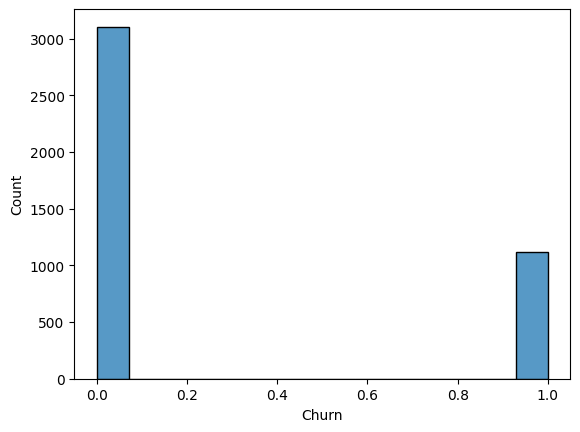

In [5]:
sn.histplot(df.Churn)

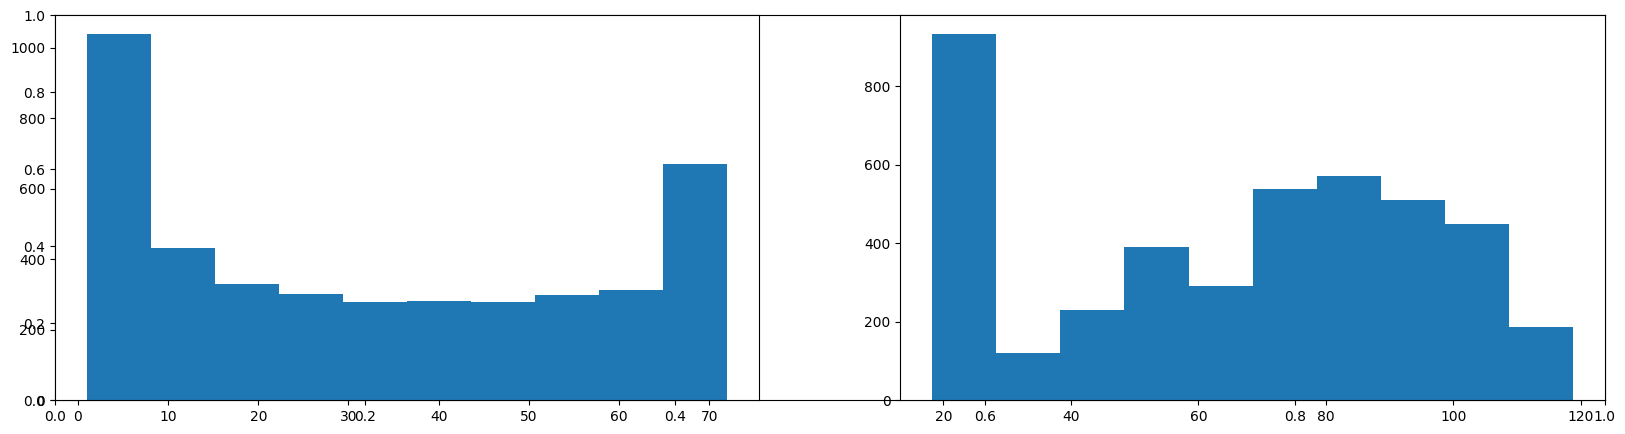

In [6]:
cols=['Tenure in Months',"Monthly Charge" ]
plt.subplots(figsize=(20,5))
for i, col in enumerate(cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col])

plt.show()

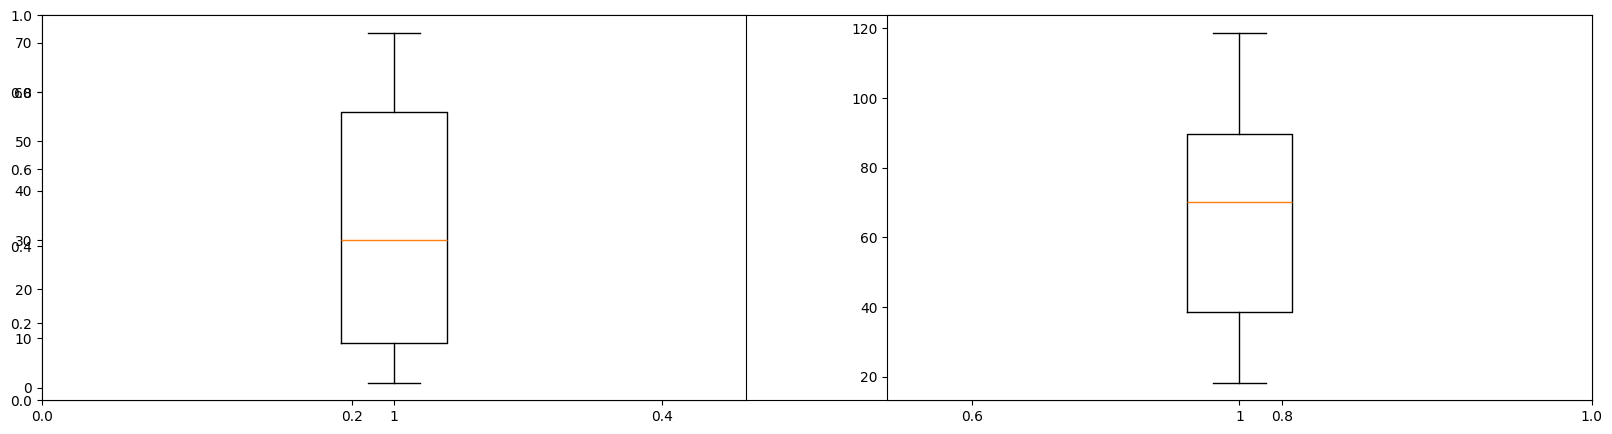

In [7]:
cols=['Tenure in Months',"Monthly Charge" ]
plt.subplots(figsize=(20,5))
for i, col in enumerate(cols):
    plt.subplot(1,2,i+1)
    plt.boxplot(df[col])

plt.show()

In [8]:
plt.figure(figsize=(12, 10))
sn.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'Two Year'

<Figure size 1200x1000 with 0 Axes>

In [ ]:
df['Contract'].unique()

array(['Two Year', 'Month-to-Month', 'One Year'], dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe=OrdinalEncoder(categories=[["Two Year",'Month-to-Month','One Year']])
df['Contract']=oe.fit_transform(df[['Contract']])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

x=df.drop('Churn',axis=1)
y=df.Churn

scaler=StandardScaler()
xnew=scaler.fit_transform(x)

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(xnew,y,test_size=0.2,random_state=42)

In [ ]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(xtrain, ytrain)

pred = model.predict(xtest)

print(f'Accuracy: {accuracy_score(ytest, pred):.4f}')
print(classification_report(ytest, pred))

In [ ]:
import pickle

with open('telco_churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('telco_churn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Saved!")